# Etsy AI Image Detection

Determine whether a product image is AI-generated (label=1) or a real photograph (label=0). \
model：EfficientNetV2-S (timm) + BCEWithLogitsLoss binary classification。\
evaluate metric：F1 Score。

## Check environment + set up path

In [1]:
# check env

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/DCU 2026 ML Challenge'
    ZIP_PATH = DATA_DIR + '/genai_image_challenge.zip'
    IMAGES_DIR = '/content/images'          
else:
    DATA_DIR = './data'
    ZIP_PATH = './data/genai_image_challenge.zip'
    IMAGES_DIR = './data/images'            

print(f'IN_COLAB: {IN_COLAB}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'IMAGES_DIR: {IMAGES_DIR}')

IN_COLAB: False
DATA_DIR: ./data
IMAGES_DIR: ./data/images


## Download PyTorch Image Models (timm) package

In [2]:
!pip install timm --quiet

## unzip file

In [3]:
import zipfile, os

if os.path.isdir(IMAGES_DIR) and len(os.listdir(IMAGES_DIR)) > 10:
    print(f'IMAGES_DIR already exists, skipping extraction ({len(os.listdir(IMAGES_DIR))} items)')
else:
    print(f'extraction now {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print('extraction complete')

items = os.listdir(IMAGES_DIR)
if len(items) == 1 and os.path.isdir(os.path.join(IMAGES_DIR, items[0])):
    IMAGES_DIR = os.path.join(IMAGES_DIR, items[0])
    print(f'detected subfolder，IMAGES_DIR update to: {IMAGES_DIR}')

print(f'number of images: {len(os.listdir(IMAGES_DIR))}')

extraction now ./data/genai_image_challenge.zip ...
extraction complete
detected subfolder，IMAGES_DIR update to: ./data/images\images_final_sample
number of images: 6858


## Import Dependencies

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
# from tqdm.auto import tqdm
from tqdm import tqdm
import random

# set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# confirm GPU available
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti


## hyper parameter define

In [5]:
MODEL_NAME = 'tf_efficientnetv2_s'    # EfficientNetV2-Small, pretrained model base on ImageNet
IMG_SIZE = 384                        
BATCH_SIZE = 24                       # 24/16  if out of memory
NUM_EPOCHS = 10                       # train round numbers
LR = 1e-4                             # Adam learning rate
if IN_COLAB:                          # Number of parallel DataLoader loading processes 0 for windows 2 for colab
    NUM_WORKERS = 2
else:
    NUM_WORKERS = 0                       
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'DEVICE: {DEVICE}')

DEVICE: cuda


## Read CSV 


In [6]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'train_df shape={train_df.shape}\n {train_df.head()}\n')
print(f'test_df shape={test_df.shape}\n {test_df.head()}\n')

train_df shape=(4800, 2)
                                    image_id  ground_truth
0  e7ea0752-f24a-4dac-926c-371fda631a0f.jpg             1
1  cdc7b8e5-1609-4f88-a20d-0dd321f8f489.jpg             0
2  c954e18f-8ab3-4bff-91d7-a0d7ff000e51.jpg             0
3  1c5fb5d5-75e0-431f-a03e-e50026f23fe3.jpg             0
4  fd0dd104-7300-4da3-a46f-6980531ead33.jpg             1

test_df shape=(2058, 1)
                                    image_id
0  3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg
1  2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg
2  01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg
3  ac784910-b461-498d-b3a8-50b1e4116b11.jpg
4  6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg



## Image Path Resolution

In [7]:

def find_image_path(image_id):
    path = os.path.join(IMAGES_DIR, image_id)
    if os.path.isfile(path):
        return path
    
    for ext in ['.jpg', '.jpeg', '.png', '.webp']:
        path = os.path.join(IMAGES_DIR, image_id + ext)
        if os.path.isfile(path):
            return path
    return None

# setup path column
train_df['path'] = train_df['image_id'].apply(find_image_path)
test_df['path'] = test_df['image_id'].apply(find_image_path)

# check mismatch
missing_train = train_df['path'].isna().sum()
missing_test = test_df['path'].isna().sum()
if missing_train > 0:
    print(f'WARNING: trainset missing {missing_train}!')
if missing_test > 0:
    print(f'WARNING: testset mismatch {missing_test}!')

print(f'Train set: {len(train_df)} rows')
print(f'Test set: {len(test_df)} rows')
print(f'\nTrain set class distribution:')
print(train_df['ground_truth'].value_counts())

Train set: 4800 rows
Test set: 2058 rows

Train set class distribution:
ground_truth
0    2485
1    2315
Name: count, dtype: int64


## Train / Validation Split
Stratified 80/20 split to preserve class distribution.

In [8]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['ground_truth']   
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print(f'Train subset: {len(train_split)} images')
print(f'Val subset: {len(val_split)} images')

Train subset: 3840 images
Val subset: 960 images


## Implements PyTorch's Dataset interface.

In [9]:
class ImageDataset(Dataset):

    def __init__(self, df, transform, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # get and convert image
        image = Image.open(row['path']).convert('RGB')

        image = self.transform(image)

        if self.has_labels:
            # BCEWithLogitsLoss requires label be float type
            label = torch.tensor(row['ground_truth'], dtype=torch.float32)
            return image, label
        else:
            # test set
            return image

## Define Image Transforms
Training uses random flips for data augmentation; validation/test uses resize and normalization only.

In [10]:
# ImageNet mean and std for normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Train transforms: random horizontal flip for data augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          
    transforms.ToTensor(),                       
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Build DataLoader
Wrap Dataset into DataLoader for batched loading and multi-process handling.

In [11]:
train_dataset = ImageDataset(train_split, transform=train_transform, has_labels=True)
val_dataset = ImageDataset(val_split, transform=val_transform, has_labels=True)

# shuffle=True 
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True    
)


val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'train batches: {len(train_loader)}')
print(f'test batches: {len(val_loader)}')

train batches: 160
test batches: 40


## Load pretrained model (EfficientNetV2-S)
replace the Classification Head (output layer) with binary classification

In [12]:
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params / 1e6:.1f}M')

Model parameters: 20.2M


## Define Loss Function and Optimizer

In [13]:
# BCEWithLogitsLoss = Sigmoid + BCELoss
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Training Loop (End-to-End Fine-tuning) 
Each epoch: train first, then validate. Save the model weights with the highest validation F1.
This is the original training procedure that produced our 0.9076 model.

In [14]:
BACKUP_MODEL_PATH = 'best_model_effnetv2s_epoch8_f1_9076.pt'
SKIP_TRAINING = True

if SKIP_TRAINING:
    print(f'Found pre-trained model: {BACKUP_MODEL_PATH}')
    print('Skipping training. To re-train, set SKIP_TRAINING=False.')
else:
    best_f1 = 0.0       
    best_epoch = -1     

    for epoch in range(NUM_EPOCHS):

        # ---- train  ----
        model.train()                       # (Dropout)
        train_loss_sum = 0.0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} Train'):
            images = images.to(DEVICE)      
            labels = labels.to(DEVICE)      

            optimizer.zero_grad()           
            logits = model(images)          
            loss = criterion(logits.squeeze(1), labels)   
            loss.backward()                 
            optimizer.step()                

            train_loss_sum += loss.item() * len(labels)

        avg_train_loss = train_loss_sum / len(train_dataset)

        # ---- validate ----
        model.eval()                        
        val_loss_sum = 0.0
        all_preds = []
        all_labels = []

        # we don't need calculate the gradient in validate round
        with torch.no_grad():               
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} Val'):
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                logits = model(images)
                loss = criterion(logits.squeeze(1), labels)
                val_loss_sum += loss.item() * len(labels)

                probs = torch.sigmoid(logits.squeeze(1))
                preds = (probs > 0.5).long()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss_sum / len(val_dataset)
        val_f1 = f1_score(all_labels, all_preds)

        print(f'Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, '
            f'val_loss={avg_val_loss:.4f}, val_f1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pt')
            print(f'  -> Saved new best model (val_f1={val_f1:.4f})')

    print(f'\nTraining done. Best val F1: {best_f1:.4f} at epoch {best_epoch+1}')

Found pre-trained model: best_model_effnetv2s_epoch8_f1_9076.pt
Skipping training. To re-train, set SKIP_TRAINING=False.


### Training Log

The following is the training log from the run that produced our final model 
(`best_model_effnetv2s_epoch8_f1_9076.pt`). Best validation F1 = **0.9076** at epoch 8.

```
Epoch  1: train_loss=1.5901  val_loss=0.6265  val_f1=0.8577   ← saved (new best)
Epoch  2: train_loss=0.1882  val_loss=0.4661  val_f1=0.8787   ← saved (new best)
Epoch  3: train_loss=0.0876  val_loss=0.5267  val_f1=0.8801   ← saved (new best)
Epoch  4: train_loss=0.0512  val_loss=0.4542  val_f1=0.8925   ← saved (new best)
Epoch  5: train_loss=0.0424  val_loss=0.5132  val_f1=0.8875
Epoch  6: train_loss=0.0326  val_loss=0.5799  val_f1=0.8898
Epoch  7: train_loss=0.0284  val_loss=0.5077  val_f1=0.8925
Epoch  8: train_loss=0.0193  val_loss=0.4963  val_f1=0.9076   ← saved (new best) ★
Epoch  9: train_loss=0.0310  val_loss=0.6188  val_f1=0.8930
Epoch 10: train_loss=0.0352  val_loss=0.5206  val_f1=0.9020

Training complete. Best val F1: 0.9076 at epoch 8.
```

### Training Log — Ablation: Strong Augmentation

Training log from the strong-augmentation ablation run (Resize 416 → RandomCrop 384, ColorJitter, RandomErasing, AdamW optimizer, 15 epochs). Best validation F1 = **0.8947** at epoch 10, **1.29 points below the light-augmentation baseline**.

```
Epoch  1: train_loss=1.6688  val_loss=0.9023  val_f1=0.8312   ← saved (new best)
Epoch  2: train_loss=0.3095  val_loss=0.5382  val_f1=0.8460   ← saved (new best)
Epoch  3: train_loss=0.1371  val_loss=0.4607  val_f1=0.8768   ← saved (new best)
Epoch  4: train_loss=0.0955  val_loss=0.4832  val_f1=0.8779   ← saved (new best)
Epoch  5: train_loss=0.0587  val_loss=0.5839  val_f1=0.8711
Epoch  6: train_loss=0.0438  val_loss=0.6160  val_f1=0.8702
Epoch  7: train_loss=0.0452  val_loss=0.6140  val_f1=0.8812   ← saved (new best)
Epoch  8: train_loss=0.0437  val_loss=0.5320  val_f1=0.8917   ← saved (new best)
Epoch  9: train_loss=0.0388  val_loss=0.6673  val_f1=0.8767
Epoch 10: train_loss=0.0403  val_loss=0.5108  val_f1=0.8947   ← saved (new best) ★
Epoch 11: train_loss=0.0344  val_loss=0.6104  val_f1=0.8750
Epoch 12: train_loss=0.0276  val_loss=0.6044  val_f1=0.8916
Epoch 13: train_loss=0.0238  val_loss=0.5559  val_f1=0.8927
Epoch 14: train_loss=0.0410  val_loss=0.5356  val_f1=0.8918
Epoch 15: train_loss=0.0337  val_loss=0.5105  val_f1=0.8782

Training complete. Best val F1: 0.8947 at epoch 10.
```

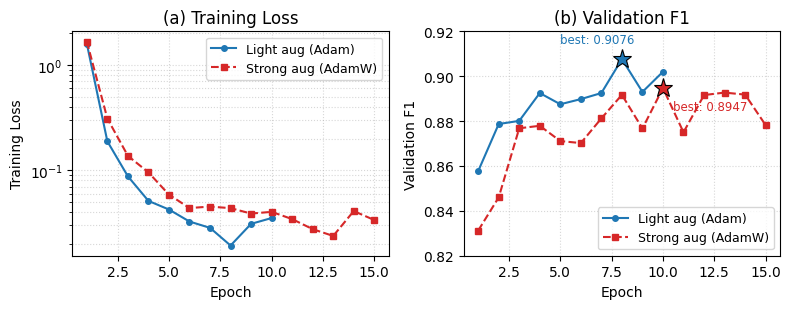

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Run 1: light augmentation, Adam, 10 epochs
run1_epochs = np.arange(1, 11)
run1_train_loss = [1.5901, 0.1882, 0.0876, 0.0512, 0.0424,
                   0.0326, 0.0284, 0.0193, 0.0310, 0.0352]
run1_val_f1 = [0.8577, 0.8787, 0.8801, 0.8925, 0.8875,
               0.8898, 0.8925, 0.9076, 0.8930, 0.9020]

# Run 2: strong augmentation, AdamW, 15 epochs
run2_epochs = np.arange(1, 16)
run2_train_loss = [1.6688, 0.3095, 0.1371, 0.0955, 0.0587,
                   0.0438, 0.0452, 0.0437, 0.0388, 0.0403,
                   0.0344, 0.0276, 0.0238, 0.0410, 0.0337]
run2_val_f1 = [0.8312, 0.8460, 0.8768, 0.8779, 0.8711,
               0.8702, 0.8812, 0.8917, 0.8767, 0.8947,
               0.8750, 0.8916, 0.8927, 0.8918, 0.8782]

# ===== Plot =====
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

# --- Left: Train loss ---
ax = axes[0]
ax.plot(run1_epochs, run1_train_loss, 'o-', label='Light aug (Adam)',
        color='#1f77b4', markersize=4, linewidth=1.5)
ax.plot(run2_epochs, run2_train_loss, 's--', label='Strong aug (AdamW)',
        color='#d62728', markersize=4, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')  
ax.set_title('(a) Training Loss')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

# --- Right: Val F1 ---
ax = axes[1]
ax.plot(run1_epochs, run1_val_f1, 'o-', label='Light aug (Adam)',
        color='#1f77b4', markersize=4, linewidth=1.5)
ax.plot(run2_epochs, run2_val_f1, 's--', label='Strong aug (AdamW)',
        color='#d62728', markersize=4, linewidth=1.5)

# Mark best epochs
ax.plot(8, 0.9076, '*', color='#1f77b4', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=5)
ax.plot(10, 0.8947, '*', color='#d62728', markersize=14,
        markeredgecolor='black', markeredgewidth=0.8, zorder=5)
ax.annotate('best: 0.9076', xy=(8, 0.9076), xytext=(5, 0.915),
            fontsize=8.5, color='#1f77b4')
ax.annotate('best: 0.8947', xy=(10, 0.8947), xytext=(10.5, 0.885),
            fontsize=8.5, color='#d62728')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation F1')
ax.set_title('(b) Validation F1')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_ylim(0.82, 0.92)

plt.tight_layout()
plt.savefig('training_curves.pdf', bbox_inches='tight', dpi=300)
plt.savefig('training_curves.png', bbox_inches='tight', dpi=200)  
plt.show()

## Load best model and evaluate (No TTA @ threshold 0.5)

In [16]:
model.load_state_dict(torch.load(BACKUP_MODEL_PATH, weights_only=True))

all_probs_plain = []
all_labels_plain = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Val No-TTA'):
        images = images.to(DEVICE)
        probs = torch.sigmoid(model(images).squeeze(1))
        all_probs_plain.extend(probs.cpu().numpy())
        all_labels_plain.extend(labels.numpy())

all_probs_plain = np.array(all_probs_plain)
all_labels_plain = np.array(all_labels_plain)

f1_at_05 = f1_score(all_labels_plain, (all_probs_plain > 0.5).astype(int))
print(f'No TTA @ threshold 0.5: {f1_at_05:.4f}')

Val No-TTA: 100%|██████████| 40/40 [00:22<00:00,  1.76it/s]

No TTA @ threshold 0.5: 0.9076


## Experiment1: TTA with default threshold

In [17]:
model.eval()
all_probs_tta = []
all_labels_tta = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Val TTA'):
        images = images.to(DEVICE)
        
        probs1 = torch.sigmoid(model(images).squeeze(1))
        probs2 = torch.sigmoid(model(torch.flip(images, dims=[3])).squeeze(1))
        probs_avg = (probs1 + probs2) / 2
        
        all_probs_tta.extend(probs_avg.cpu().numpy())
        all_labels_tta.extend(labels.numpy())

all_probs_tta = np.array(all_probs_tta)
all_labels_tta = np.array(all_labels_tta)

preds_tta = (all_probs_tta > 0.5).astype(int)
val_f1_tta = f1_score(all_labels_tta, preds_tta)
print(f'Val F1 with TTA: {val_f1_tta:.4f}  (without TTA: {f1_at_05:.4f})')

Val TTA: 100%|██████████| 40/40 [00:13<00:00,  2.93it/s]

Val F1 with TTA: 0.9053  (without TTA: 0.9076)


## Experiment2: TTA + Threshold search

In [18]:
best_thresh_tta = 0.5
best_thresh_f1 = 0.0

for t in np.arange(0.30, 0.71, 0.01):
    preds_t = (all_probs_tta > t).astype(int)
    f1_t = f1_score(all_labels_tta, preds_t)
    if f1_t > best_thresh_f1:
        best_thresh_f1 = f1_t
        best_thresh_tta = t

print(f'Best threshold: {best_thresh_tta:.2f}, Val F1: {best_thresh_f1:.4f}')
print(f'(vs default 0.5: {val_f1_tta:.4f})')

Best threshold: 0.48, Val F1: 0.9066
(vs default 0.5: 0.9053)


## Experiment3: NO TTA + Threshold search 

In [19]:
best_thresh_plain = 0.5
best_f1_plain = 0.0
for t in np.arange(0.30, 0.71, 0.01):
    f1_t = f1_score(all_labels_plain, (all_probs_plain > t).astype(int))
    if f1_t > best_f1_plain:
        best_f1_plain = f1_t
        best_thresh_plain = t
print(f'No TTA @ threshold 0.5: {f1_at_05:.4f}')
print(f'No TTA @ threshold {best_thresh_plain:.2f}: {best_f1_plain:.4f}')

No TTA @ threshold 0.5: 0.9076
No TTA @ threshold 0.53: 0.9085


## Load best model

In [20]:
model.load_state_dict(torch.load(BACKUP_MODEL_PATH, weights_only=True))
model.eval()
print('Best model loaded.')

Best model loaded.


## Prediction on test set

In [21]:
FINAL_THRESHOLD = 0.5
test_dataset = ImageDataset(test_df, transform=val_transform, has_labels=False)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

predictions = []

model.eval()
with torch.no_grad():
    for images in tqdm(test_loader, desc='Test Inference'):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits.squeeze(1))
        preds = (probs > FINAL_THRESHOLD).long()
        predictions.extend(preds.cpu().numpy())

test_df['prediction'] = predictions
print(f'Prediction  complete, {len(predictions)} predictions in total')
print(f'Threshold used: {FINAL_THRESHOLD:.2f}')


Test Inference: 100%|██████████| 86/86 [00:37<00:00,  2.27it/s]

Prediction  complete, 2058 predictions in total
Threshold used: 0.50


## Save to submission.csv

In [22]:
submission = test_df[['image_id', 'prediction']]
submission.to_csv('submission.csv', index=False)

print('Saved submission.csv')
print(f'\nPrediction distribution:')
print(submission['prediction'].value_counts())
print(f'\nFirst 5 rows:')
print(submission.head())

Saved submission.csv

Prediction distribution:
prediction
1    1066
0     992
Name: count, dtype: int64

First 5 rows:
                                   image_id  prediction
0  3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg           0
1  2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg           0
2  01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg           0
3  ac784910-b461-498d-b3a8-50b1e4116b11.jpg           0
4  6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg           0
